In [85]:
import sympy
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from evolml.models import *
from sklearn.metrics import r2_score, roc_auc_score
import numpy as np
%matplotlib inline

# Explicit expression classifier

In [86]:
X = np.linspace(-1, 1, 1000).reshape([-1, 1])
y_c = ((4*X**2 + X - 1) > 0).astype(int)
y_r = (4*X**2 + X - 1)

X_train, X_test = X[::2], X[1::2]
y_c_train, y_c_test = y_c[::2], y_c[1::2]
y_r_train, y_r_test = y_r[::2], y_r[1::2]

X_train.shape, X_test.shape, y_c_train.shape, y_c_test.shape

((500, 1), (500, 1), (500, 1), (500, 1))

In [87]:
X_train.flatten()

array([-1.        , -0.995996  , -0.99199199, -0.98798799, -0.98398398,
       -0.97997998, -0.97597598, -0.97197197, -0.96796797, -0.96396396,
       -0.95995996, -0.95595596, -0.95195195, -0.94794795, -0.94394394,
       -0.93993994, -0.93593594, -0.93193193, -0.92792793, -0.92392392,
       -0.91991992, -0.91591592, -0.91191191, -0.90790791, -0.9039039 ,
       -0.8998999 , -0.8958959 , -0.89189189, -0.88788789, -0.88388388,
       -0.87987988, -0.87587588, -0.87187187, -0.86786787, -0.86386386,
       -0.85985986, -0.85585586, -0.85185185, -0.84784785, -0.84384384,
       -0.83983984, -0.83583584, -0.83183183, -0.82782783, -0.82382382,
       -0.81981982, -0.81581582, -0.81181181, -0.80780781, -0.8038038 ,
       -0.7997998 , -0.7957958 , -0.79179179, -0.78778779, -0.78378378,
       -0.77977978, -0.77577578, -0.77177177, -0.76776777, -0.76376376,
       -0.75975976, -0.75575576, -0.75175175, -0.74774775, -0.74374374,
       -0.73973974, -0.73573574, -0.73173173, -0.72772773, -0.72

In [88]:
model = ExplicitPSClassifier("p_0 * x_0**2 + p_1 * x_0 + p_2")

model = model.fit(X_train, y_c_train)

Initializing optimization of Symbolic regression using PSO
----------------------------------------------------------

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.4 s
	CPU time Spent:  0.4 s
	Generation: 0
	Best fitness: 0.81
	Evaluations of fitness: 100

	diversity: 39.5
	mean speed: 0.524

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.7 s
	CPU time Spent:  0.7 s
	Generation: 1
	Best fitness: 0.82
	Evaluations of fitness: 200

	diversity: 39.7
	mean speed: 2.56

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.47 s
	CPU time Spent:  1.47 s
	Generation: 3
	Best fitness: 0.82
	Evaluations of fitness: 400

	diversity: 52.7
	mean speed: 0.916

Optimizing Symbolic regression using PSO:
	Real time Spent: 2.14 s
	CPU time Spent:  2.14 s
	Generation: 5
	Best fitness: 0.934
	Evaluations of fitness: 600

	diversity: 45.6
	mean speed: 20.8

Optimizing Symbolic regression using PSO:
	Real time Spent: 2.72 s
	CPU time Spent:  2.72 s
	Generation: 7
	Be

In [89]:
y_pred = model.predict(X_test)
roc_auc_score(y_pred, y_c_test)

0.998062015503876

In [90]:
print("Resulting Equation:")
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
display(eq)

Resulting Equation:


Eq(100.0*x_0**2 + 25.161438738747*x_0 - 25.0829972584874, 0)

x_0 x_1


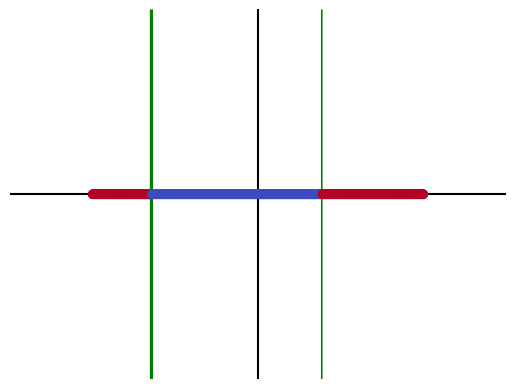

In [91]:
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
x, y = sympy.symbols("x_0 x_1")
print(x, y)

p = sympy.plot_implicit(eq, x, y, show=False, line_color="green", adaptive=True, axis=False)
p._backend.process_series()
plt_fig = p._backend.fig
plt_ax = p._backend.ax
plt_ax = backend.plt
plt_ax.scatter(X, X*0, c=y_c, cmap="coolwarm", zorder=2)
plt_ax.axvline(0, color="black", zorder=-1)
plt_ax.axhline(0, color="black", zorder=-1)
plt.xlim(-1.5, 1.5)
plt.show()

# Explicit function regression

In [92]:
model = ExplicitPSRegressor("p_0 * x_0**2 + p_1 + x_0 + p_2")

model = model.fit(X_train, y_r_train)

Initializing optimization of Symbolic regression using PSO
----------------------------------------------------------

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.26 s
	CPU time Spent:  0.26 s
	Generation: 0
	Best fitness: 3.1370863471487307
	Evaluations of fitness: 100

	diversity: 45.3
	mean speed: 0.497

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.51 s
	CPU time Spent:  0.51 s
	Generation: 1
	Best fitness: 2.369973489676636
	Evaluations of fitness: 200

	diversity: 54.5
	mean speed: -3.11

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.23 s
	CPU time Spent:  1.23 s
	Generation: 4
	Best fitness: 0.11129698616550351
	Evaluations of fitness: 500

	diversity: 77.6
	mean speed: 0.39

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.9 s
	CPU time Spent:  1.9 s
	Generation: 7
	Best fitness: 0.11129698616550351
	Evaluations of fitness: 800

	diversity: 82.0
	mean speed: -1.62

Optimizing Symbolic regression using PSO:
	Real tim

In [93]:
y_pred = model.predict(X_test)
r2_score(y_pred, y_r_test)

1.0

In [94]:
print("Resulting Equation:")
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
display(eq)

Resulting Equation:


Eq(4.0*x_0**2 + x_0 - 1.0, x_1)

x_0 x_1


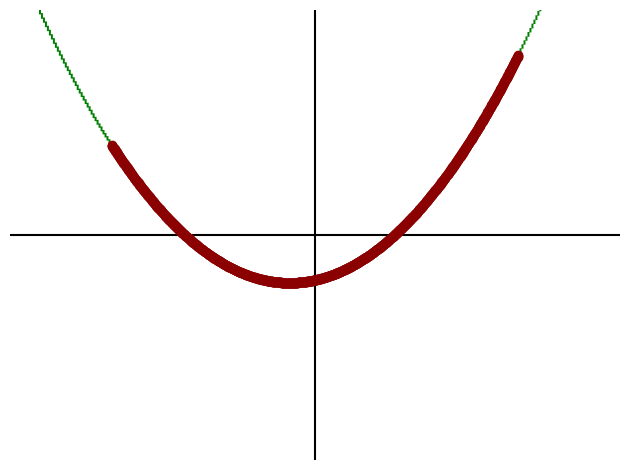

In [95]:
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
x, y = sympy.symbols("x_0 x_1")
print(x, y)

p = sympy.plot_implicit(eq, x, y, show=False, line_color="green", adaptive=True, axis=False)
p._backend.process_series()
plt_fig = p._backend.fig
plt_ax = p._backend.ax
plt_ax.scatter(X, y_r, c="darkred", zorder=2)
plt_ax.axvline(0, color="black", zorder=-1)
plt_ax.axhline(0, color="black", zorder=-1)
plt_ax.set_xlim(-1.5, 1.5)
plt_fig.tight_layout()
plt.show()
